In [7]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('week1/insurance.csv')
 
print(df.head())
print(df.shape)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)


In [8]:
print(df.isnull().sum())
print(df.describe())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [11]:
# BMI Category

df['bmi_category'] = pd.cut(df['bmi'], 
    bins = [0, 18.5, 24.9,29.9,100],
    labels = ['Underweight', 'Normal', 'Overweight', 'Obese'])

print(df['bmi_category'].value_counts(normalize=True). round(1) * 100)

bmi_category
Obese          50.0
Overweight     30.0
Normal         20.0
Underweight     0.0
Name: proportion, dtype: float64


In [15]:
# Risk tier based on BMI and smoker status 

def assign_risk_tier(row):
    if row['smoker'] == 'yes' and row['bmi_category'] == 'Obese':
        return 'Very High'
    elif row['smoker'] == 'yes':
        return 'High'
    elif row['bmi_category'] == 'Obese':
        return 'Medium'
    else:
        return 'Low'

df['risk_tier'] = df.apply(assign_risk_tier, axis=1)

print(df['risk_tier'].value_counts())
print()
print(df.groupby('risk_tier')['charges'].mean().round(2).sort_values(ascending=False))

risk_tier
Medium       569
Low          495
Very High    147
High         127
Name: count, dtype: int64

risk_tier
Very High    41355.87
High         21279.14
Medium        8809.55
Low           8002.89
Name: charges, dtype: float64


In [23]:
# average charges by region and risk tier 

regional_charge = df.groupby(['region', 'risk_tier'])[
    'charges'].mean().round(2).unstack()

print(regional_charge) 

risk_tier      High      Low    Medium  Very High
region                                           
northeast  20775.26  8276.99  10280.10   40648.08
northwest  22152.99  8076.00   9086.10   42425.28
southeast  21534.42  7901.64   8089.26   42064.29
southwest  20404.78  7684.83   8331.93   40065.59


risk tier is the primary pricing driver, region is a secondary modifier.

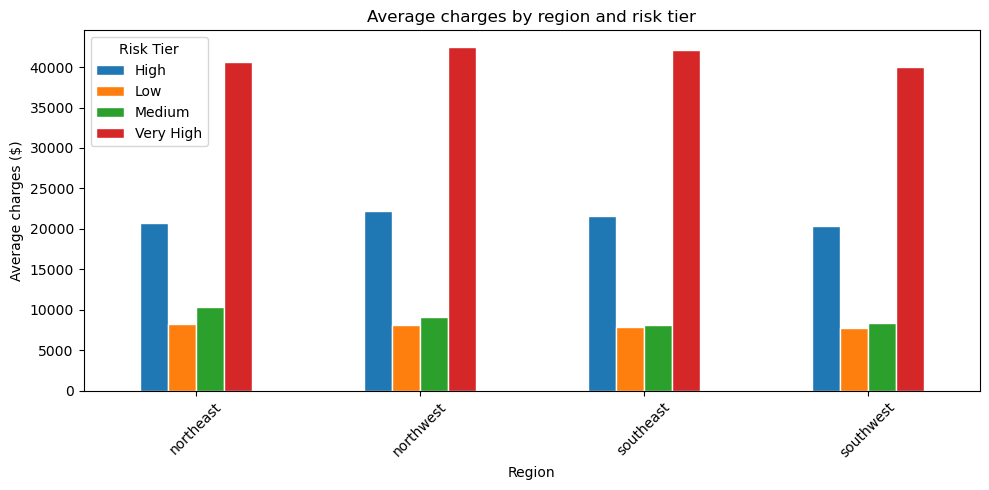

In [26]:
regional_charge.plot(
    kind='bar',
    figsize=(10, 5),
    edgecolor= 'white')

plt.title('Average charges by region and risk tier')
plt.xlabel('Region')
plt.ylabel('Average charges ($)')
plt.xticks(rotation=45)
plt.legend(title='Risk Tier')
plt.tight_layout()
plt.show()

